In [2]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
import pickle
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Evaluating model: large mlp
Evaluating model: linear model
Evaluating model: medium mlp
Evaluating model: small mlp


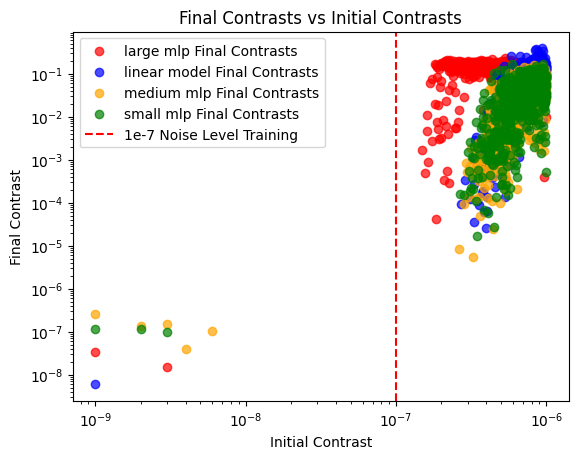

In [ ]:
eval_dir = 'evals'
pkl_files = [f for f in os.listdir(eval_dir) if f.endswith('.pkl')]

# fig, axes = plt.subplots(nrows = len(pkl_files), ncols=1, figsize=(8, 6 * len(pkl_files)))

model_stats = {}

colors = ["red", "blue", "orange", "green", "purple", "brown"]

for pkl_file in pkl_files:
    with open(os.path.join(eval_dir, pkl_file), 'rb') as f:
        eval_data = pickle.load(f)

    model_name = pkl_file.replace('.pkl', '')[5:]
    print(f'Evaluating model: {model_name}')
    
    # Example visualization: Plotting the reward over episodes
    final_contrasts = eval_data['final_contrasts']
    initial_contrasts = eval_data['initial_contrasts']
    noise_levels = eval_data['noise_levels']
    cos_similarities = eval_data['cos_similarities']
    predictions = eval_data['predictions']
    truths = eval_data['truths']
    model_stats[model_name] = {
        'final_contrasts': final_contrasts,
        'initial_contrasts': initial_contrasts,
        'noise_levels': noise_levels,
        'cos_similarities': cos_similarities,
        'predictions': predictions,
        'truths': truths
    }

    differences = final_contrasts - initial_contrasts

    print(differences.shape)

    

    plt.scatter(noise_levels, final_contrasts, label=f'{model_name} Final Contrasts', alpha=0.7, color=colors[pkl_files.index(pkl_file) % len(colors)])
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Final Contrasts vs Initial Contrasts')
    plt.xlabel('Initial Contrast')
    plt.ylabel('Final Contrast')



    # ax = axes[pkl_files.index(pkl_file)]
    # ax.set_title(f'Final Contrasts {model_name}')
    # ax.set_xlabel('Initial Contrast')
    # ax.set_ylabel('Final Contrast')
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # differences = final_contrasts - initial_contrasts

    # ax.scatter(noise_levels, final_contrasts, c=-differences, cmap='RdYlGn', alpha=0.7)
# plt.axhline(y=3.88e-08, color="black", linestyle="--", label="Min Contrast for Sim")
plt.axvline(x=1e-7, color="red", linestyle="--", label="1e-7 Noise Level Training")
plt.legend()    

plt.show()

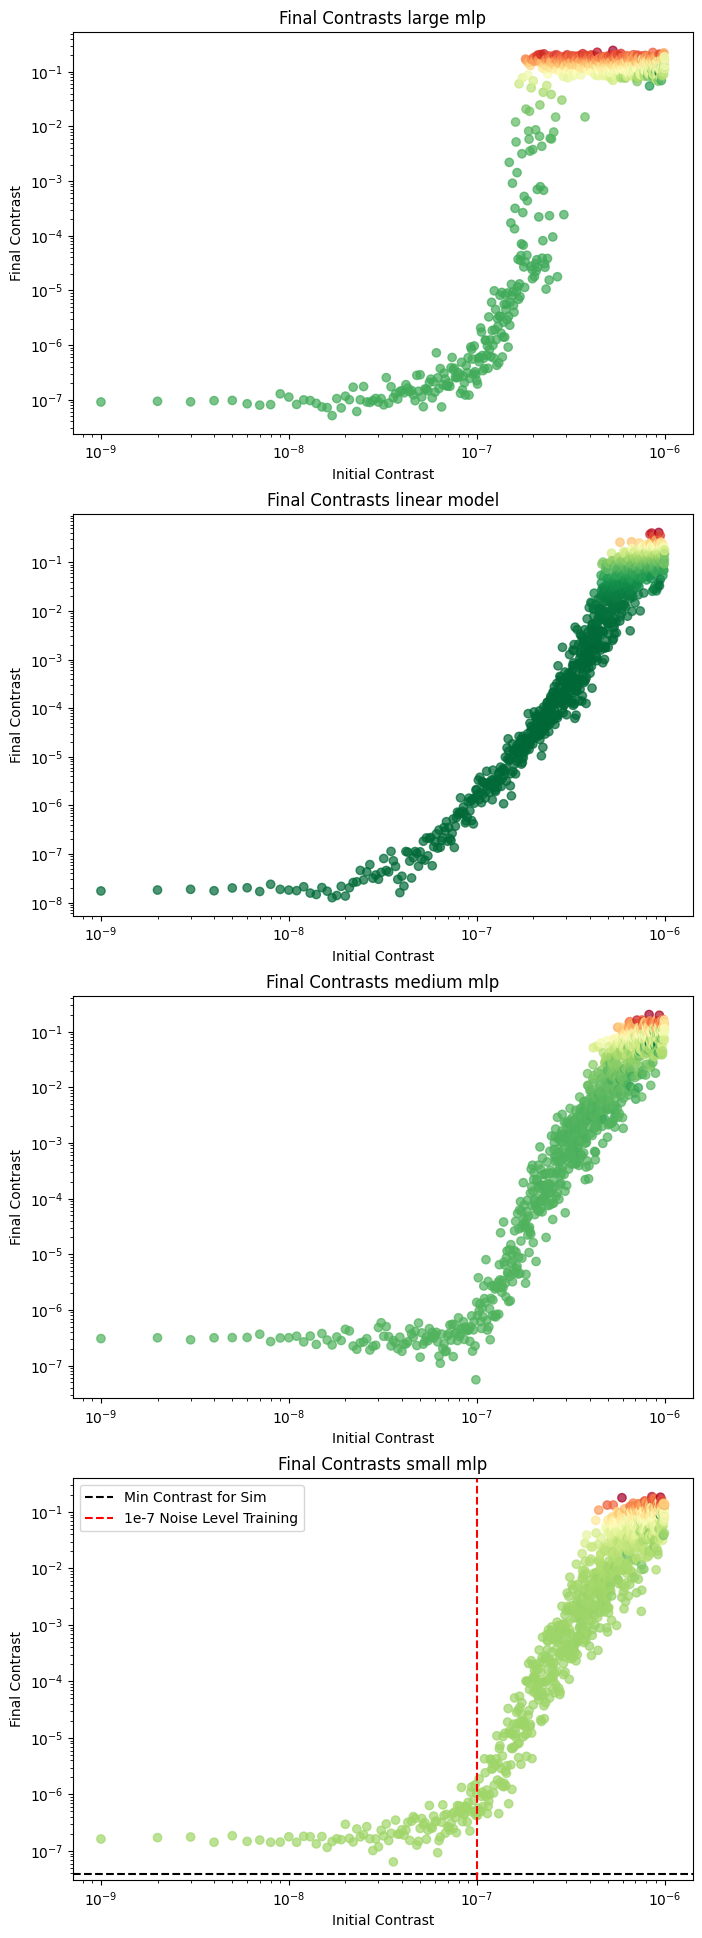

In [61]:
fig, axes = plt.subplots(nrows = len(pkl_files), ncols=1, figsize=(8, 6 * len(pkl_files)))

colors = ["red", "blue", "orange", "green", "purple", "brown"]

for i, (model_name, data) in enumerate(model_stats.items()):
    (final_contrasts, initial_contrasts, noise_levels, cos_similarities, predictions, truths) = data.values()
    
    differences = final_contrasts - initial_contrasts
    mean_improvement = np.mean(differences)
    max_improvement = np.max(differences)
    avg_cosine_similarity = np.mean(cos_similarities)

    
    ax = axes[i]
    ax.set_title(f'Final Contrasts {model_name}')
    ax.set_xlabel('Initial Contrast')
    ax.set_ylabel('Final Contrast')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.scatter(noise_levels, final_contrasts, c=-differences, cmap='RdYlGn', alpha=0.7)

plt.axhline(y=3.88e-08, color="black", linestyle="--", label="Min Contrast for Sim")
plt.axvline(x=1e-7, color="red", linestyle="--", label="1e-7 Noise Level Training")
plt.legend()    
plt.show()

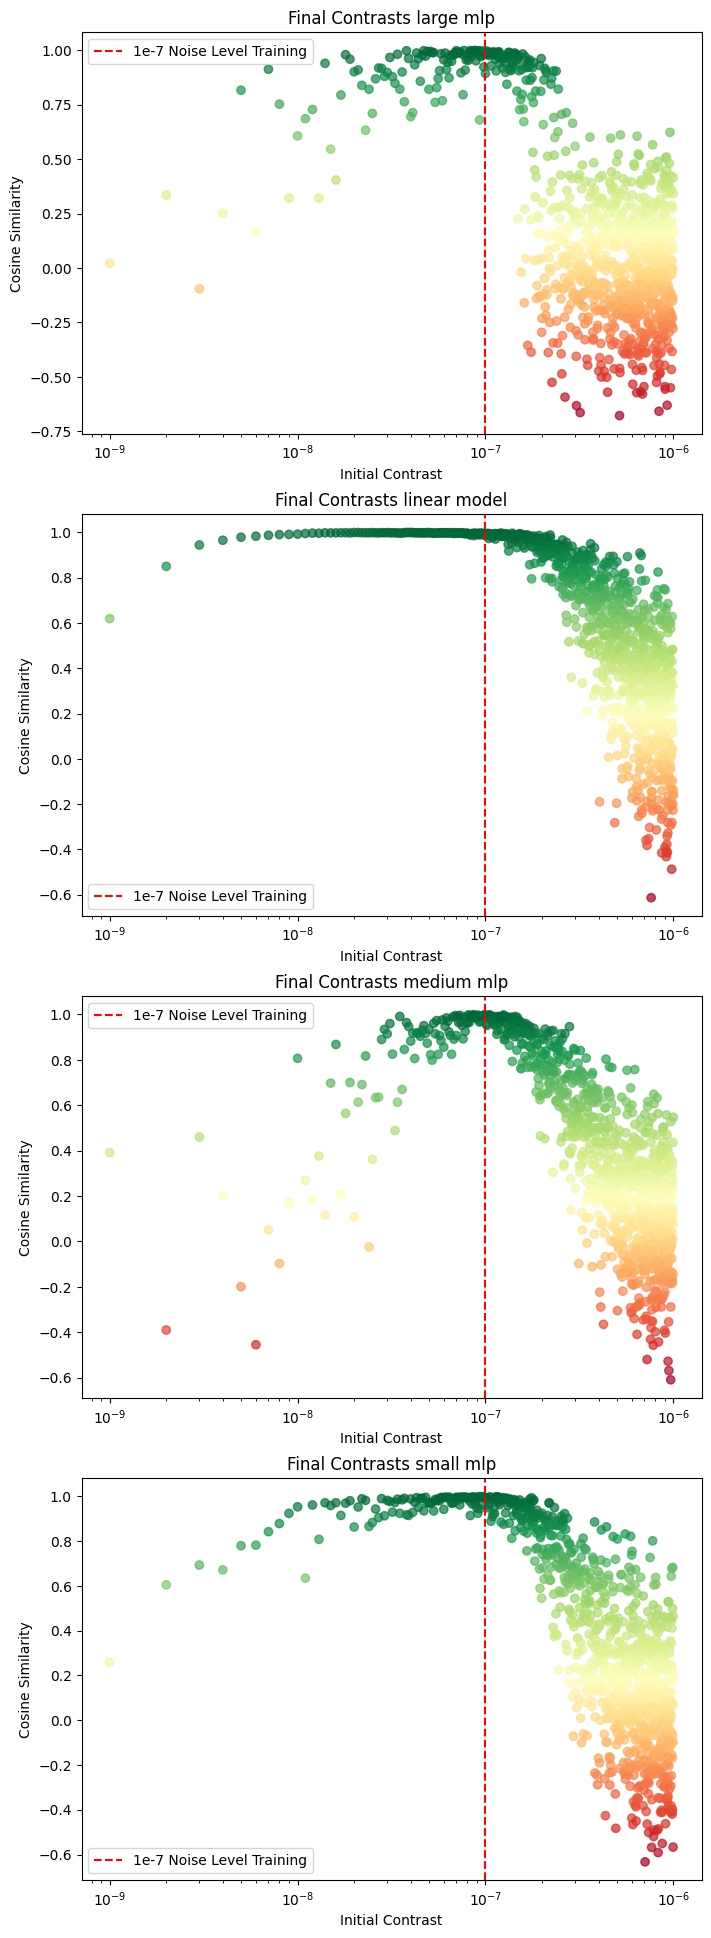

In [65]:
fig, axes = plt.subplots(nrows = len(pkl_files), ncols=1, figsize=(8, 6 * len(pkl_files)))

colors = ["red", "blue", "orange", "green", "purple", "brown"]

for i, (model_name, data) in enumerate(model_stats.items()):
    (final_contrasts, initial_contrasts, noise_levels, cos_similarities, predictions, truths) = data.values()
    
    differences = final_contrasts - initial_contrasts
    mean_improvement = np.mean(differences)
    max_improvement = np.max(differences)
    avg_cosine_similarity = np.mean(cos_similarities)

    
    ax = axes[i]
    ax.set_title(f'Final Contrasts {model_name}')
    ax.set_xlabel('Initial Contrast')
    ax.set_ylabel('Cosine Similarity')
    ax.set_xscale('log')
    ax.scatter(noise_levels, cos_similarities, c=cos_similarities, cmap='RdYlGn', alpha=0.7)
    ax.axvline(x=1e-7, color="red", linestyle="--", label="1e-7 Noise Level Training")
    ax.legend()

  
plt.show()